**K-Nearest Neighbors (KNN)** is a simple, intuitive, non-parametric machine learning algorithm used for both **classification** and **regression**.

Instead of building a complex mathematical model during a "training" phase, KNN simply memorizes the existing dataset. When given a new, unlabeled data point, it finds the **$K$ closest data points** (its "neighbors") in the feature space and assigns a value based on them.

---

## How It Works (Step-by-Step)

1. **Choose $K$:** Select the number of nearest neighbors to evaluate (e.g., $K = 3$ or $K = 5$).
2. **Calculate Distance:** Measure the distance between the new data point and all existing data points in the dataset (most commonly using **Euclidean Distance**).
3. **Find Nearest Neighbors:** Identify the $K$ points that are closest to the new point.
4. **Make a Prediction:**
* **For Classification:** Take a majority vote among the $K$ neighbors. The new point is assigned the class that occurs most frequently.
* **For Regression:** Calculate the average (mean or median) of the target values of the $K$ neighbors.



---

## Distance Metrics

To determine which neighbors are "closest," KNN relies on distance formulas:

* **Euclidean Distance** (Straight-line distance):

$$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$


* **Manhattan Distance** (Grid-based/taxicab distance):

$$d(p, q) = \sum_{i=1}^{n} \vert{}q_i - p_i\vert{}$$


* **Minkowski Distance** (Generalized distance framework):

$$d(p, q) = \left( \sum_{i=1}^{n} \vert{}q_i - p_i\vert{}^p \right)^{\frac{1}{p}}$$



---

## Choosing the Optimal Value of $K$

* **Small $K$ (e.g., $K = 1$):** Very sensitive to noise and outliers in the dataset. Can easily lead to **overfitting**.
* **Large $K$:** Smooths out the decision boundary, but if $K$ is too large, it may include points from other classes, leading to **underfitting**.
* **Best Practice:** Use an **odd number** for $K$ in binary classification to prevent tie votes, and select the optimal value using cross-validation.

---

## Pros & Cons

| Advantages | Disadvantages |
| --- | --- |
| **Simple to understand:** Easy to implement and explain. | **Computationally Expensive:** Requires computing distances to all points for every new query ($O(N \cdot D)$ time complexity). |
| **No Training Phase:** Fast setup as it is a "lazy learner." | **Sensitive to Scale:** Unscaled features with large ranges dominate distance calculations. Feature scaling (Standardization/Normalization) is required. |
| **Adaptable:** Handles multi-class targets and continuous outputs easily. | **Curse of Dimensionality:** Performance drastically decreases as the number of features/dimensions grows. |

# K-Nearest Neighbors (KNN) Implementation
This notebook demonstrates how to prepare data, train a KNN classifier, evaluate performance, and visualize decision boundaries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Display dataset details
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Explanation

This cell imports the libraries for data handling, visualization, scaling, and the KNN model evaluation workflow.



In [2]:
# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for distance-based algorithms like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape:  {X_test_scaled.shape}")

Training set shape: (120, 4)
Testing set shape:  (30, 4)


### Explanation

The data is split into training and testing sets, and the features are scaled because KNN relies on distance calculations and large-value features can distort the results.



In [3]:
# Initialize KNN classifier with K = 5
k = 5
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

# Fit the model (KNN simply stores the training data)
knn.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test_scaled)
print(f"Model trained successfully with K = {k}")

Model trained successfully with K = 5


### Explanation

This block initializes a KNN classifier, trains it on the scaled training data, and predicts the labels for the test set.



Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



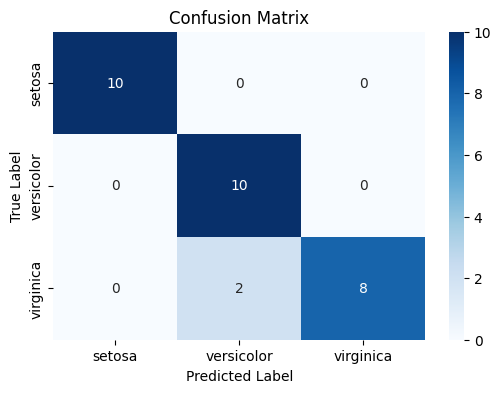

In [4]:
# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%\n")

# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Explanation

The accuracy and a classification report are computed to measure how well the KNN model generalizes to unseen data.



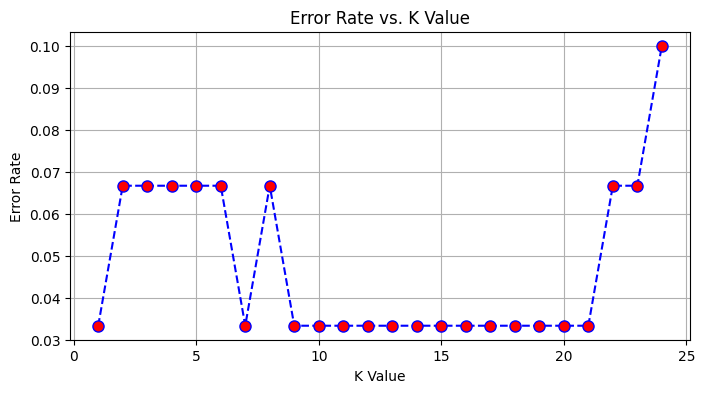

In [5]:
# Evaluate accuracy across a range of K values
error_rates = []
k_range = range(1, 25)

for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_scaled, y_train)
    predictions = clf.predict(X_test_scaled)
    error_rates.append(np.mean(predictions != y_test))

# Plot Error Rate vs. K Value
plt.figure(figsize=(8, 4))
plt.plot(k_range, error_rates, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

### Explanation

This loop evaluates several values of k to identify the neighborhood size that yields the best performance on the validation/test data.



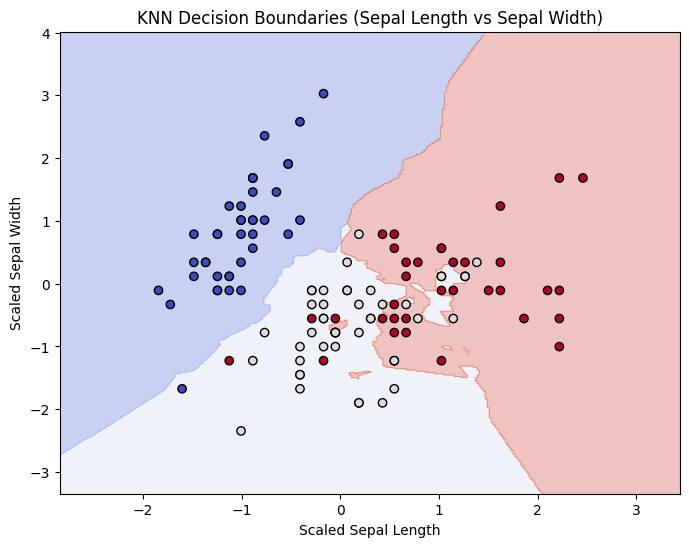

In [6]:
# Select first two features for 2D visualization
X_2d = X_train_scaled[:, :2]
y_2d = y_train

clf_2d = KNeighborsClassifier(n_neighbors=5)
clf_2d.fit(X_2d, y_2d)

# Create a mesh grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict across grid
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("KNN Decision Boundaries (Sepal Length vs Sepal Width)")
plt.xlabel("Scaled Sepal Length")
plt.ylabel("Scaled Sepal Width")
plt.show()

### Explanation

The model is reduced to two features to draw a 2D decision boundary and visually show how the KNN algorithm separates classes.

